# ADC Async Technical Report

## Methods

Asynchronous differential ADC testing was performed using the same 10 Hz sinusoidal input and oscilloscope reference signal used for the synchronous buffered measurements. The input waveform was saved as a scope CSV file, and for each asynchronous acquisition the logged HEX buffer was copied from the terminal into text files for later analysis. As in the synchronous case, the ADC samples were decoded in a Jupyter notebook using read_hex_data() and unwrap_twos_complement(), converted to voltage, and plotted against the oscilloscope waveform for comparison. Separate datasets were collected for nominal sampling at 200 Hz and aliased sampling at 5 Hz so that the asynchronous implementation could be compared directly to the earlier synchronous buffered results.

For each run, the sampled waveform was overlaid on the input signal and the dominant sampled frequency was estimated from the decoded ADC data. Three runs were analyzed for each sampling condition, and mean values and 95% confidence intervals were calculated from the replicate frequency estimates. These asynchronous results were then compared qualitatively and quantitatively to the synchronous buffered notebook by examining waveform shape, frequency agreement, and aliasing behavior at the reduced sampling rate. The comparison focused on whether the asynchronous method preserved the same sampled signal characteristics while changing only the acquisition control flow.

## Results

### Scope vs. ADC Hex Data

Loaded scope data from scope_async.csv
Scope samples: 6400
Detected 3 nominal runs in adc_async_nominal.txt
Detected 3 aliased runs in adc_async_alias.txt

Async Nominal Sampling (200 Hz)
-------------------------------
Run 1: estimated sampled frequency = 10.00 Hz


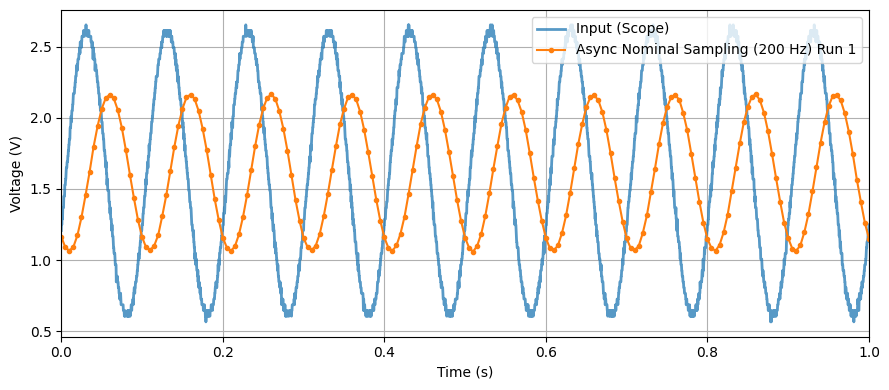

Run 2: estimated sampled frequency = 10.00 Hz


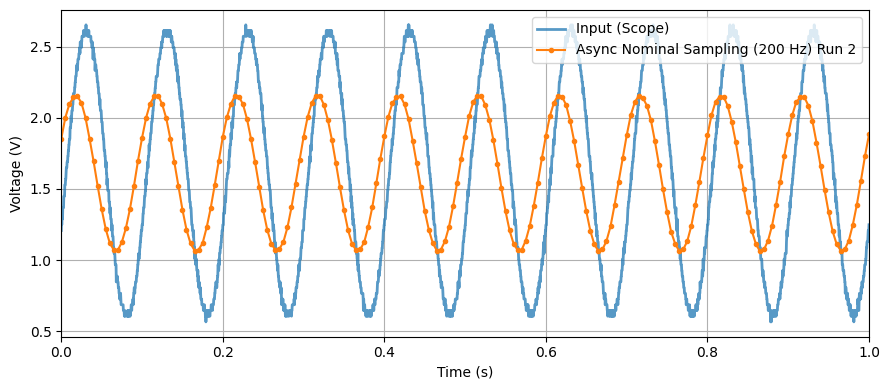

Run 3: estimated sampled frequency = 10.00 Hz


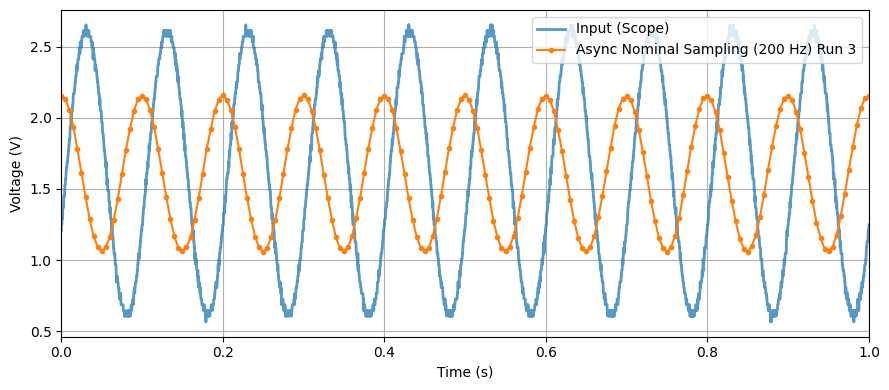


Async Aliased Sampling (5 Hz)
-----------------------------
Run 1: estimated sampled frequency = 2.50 Hz


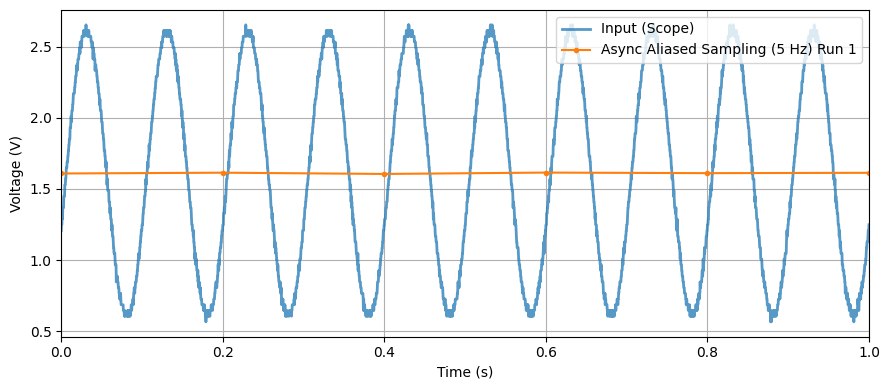

Run 2: estimated sampled frequency = 2.50 Hz


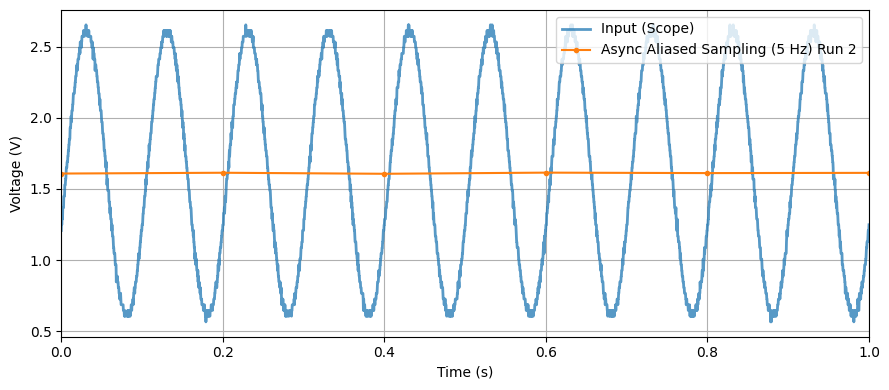

Run 3: estimated sampled frequency = 0.50 Hz


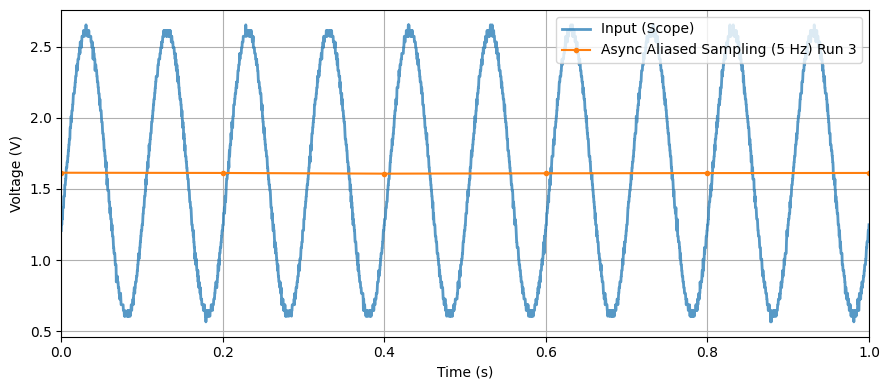

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bme554 import read_hex_data, unwrap_twos_complement

SAMPLES_NOMINAL = 400
SAMPLES_ALIAS = 10
VREF = 3.3
RESOLUTION = 4096

NOMINAL_FS = 200.0
ALIASED_FS = 5.0

SCOPE_FILE = "scope_async.csv"
NOMINAL_FILE = "adc_async_nominal.txt"
ALIASED_FILE = "adc_async_alias.txt"

TMAX_PLOT = 1

def estimate_freq_fft(signal, fs):
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(N, d=1/fs)
    if len(fft_vals) <= 1:
        return np.nan
    idx = np.argmax(np.abs(fft_vals[1:])) + 1
    return fft_freqs[idx]

def split_hex_runs(filename, samples_per_run):
    hex_data = read_hex_data(filename)
    bytes_per_run = 2 * samples_per_run
    runs = []
    for i in range(0, len(hex_data), bytes_per_run):
        chunk = hex_data[i:i + bytes_per_run]
        if len(chunk) == bytes_per_run:
            runs.append(chunk)
    return runs

def decode_run(run_chunk, vref, resolution):
    adc_vals = np.array(unwrap_twos_complement(run_chunk), dtype=float)
    return (adc_vals / resolution) * vref

def load_scope_csv(scope_file):
    df = pd.read_csv(scope_file, header=None, skiprows=2)
    t_scope = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    v_scope = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    valid = t_scope.notna() & v_scope.notna()
    t_scope = t_scope[valid].to_numpy(dtype=float)
    v_scope = v_scope[valid].to_numpy(dtype=float)
    t_scope = t_scope - t_scope[0]
    return t_scope, v_scope

def match_offset(t_ref, y_ref, t_sig, y_sig, tmax):
    ref_mask = t_ref <= tmax
    sig_mask = t_sig <= tmax
    if not np.any(ref_mask) or not np.any(sig_mask):
        return y_sig
    ref_mean = np.mean(y_ref[ref_mask])
    sig_mean = np.mean(y_sig[sig_mask])
    return y_sig + (ref_mean - sig_mean)

def plot_runs(runs, fs, case_name, t_scope, v_scope):
    print(f"\n{case_name}")
    print("-" * len(case_name))
    scope_mask = t_scope <= TMAX_PLOT
    t_scope_plot = t_scope[scope_mask]
    v_scope_plot = v_scope[scope_mask]
    run_freqs = []
    for i, run in enumerate(runs, start=1):
        adc_voltage = decode_run(run, VREF, RESOLUTION)
        t_adc = np.arange(len(adc_voltage)) / fs
        freq = estimate_freq_fft(adc_voltage, fs)
        run_freqs.append(freq)
        print(f"Run {i}: estimated sampled frequency = {freq:.2f} Hz")
        adc_voltage_aligned = match_offset(t_scope_plot, v_scope_plot, t_adc, adc_voltage, TMAX_PLOT)
        adc_mask = t_adc <= TMAX_PLOT
        t_adc_plot = t_adc[adc_mask]
        adc_plot = adc_voltage_aligned[adc_mask]
        plt.figure(figsize=(9, 4))
        plt.plot(t_scope_plot, v_scope_plot, label="Input (Scope)", linewidth=2, alpha=0.75)
        plt.plot(t_adc_plot, adc_plot, "o-", label=f"{case_name} Run {i}", markersize=3)
        plt.xlim(0, TMAX_PLOT)
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()
    return np.array(run_freqs, dtype=float)

t_scope, v_scope = load_scope_csv(SCOPE_FILE)
print(f"Loaded scope data from {SCOPE_FILE}")
print(f"Scope samples: {len(t_scope)}")

nominal_runs = split_hex_runs(NOMINAL_FILE, SAMPLES_NOMINAL)
aliased_runs = split_hex_runs(ALIASED_FILE, SAMPLES_ALIAS)

print(f"Detected {len(nominal_runs)} nominal runs in {NOMINAL_FILE}")
print(f"Detected {len(aliased_runs)} aliased runs in {ALIASED_FILE}")

nominal_freqs = plot_runs(nominal_runs, NOMINAL_FS, "Async Nominal Sampling (200 Hz)", t_scope, v_scope)
aliased_freqs = plot_runs(aliased_runs, ALIASED_FS, "Async Aliased Sampling (5 Hz)", t_scope, v_scope)

### Calculating CI and Error

In [5]:
import numpy as np
from scipy import stats

TRUE_INPUT_FREQ = 10.0

def mean_ci_95(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)

    if n == 0:
        return np.nan, np.nan
    if n == 1:
        return np.mean(x), 0.0

    mean = np.mean(x)
    sd = np.std(x, ddof=1)
    sem = sd / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, df=n - 1)
    ci = tcrit * sem
    return mean, ci

def theoretical_alias_frequency(f_signal, fs):
    k = round(f_signal / fs)
    return abs(f_signal - k * fs)

nom_mean, nom_ci = mean_ci_95(nominal_freqs)
ali_mean, ali_ci = mean_ci_95(aliased_freqs)

nom_pct_error = 100 * (nom_mean - TRUE_INPUT_FREQ) / TRUE_INPUT_FREQ
ali_pct_error = 100 * (ali_mean - TRUE_INPUT_FREQ) / TRUE_INPUT_FREQ

alias_theoretical = theoretical_alias_frequency(TRUE_INPUT_FREQ, ALIASED_FS)

print("\n200 Hz Sampling")
print("---------------")
print(f"n = {len(nominal_freqs)}")
print(f"Mean frequency = {nom_mean:.2f} Hz")
print(f"95% CI = [{nom_mean - nom_ci:.2f}, {nom_mean + nom_ci:.2f}] Hz")
print(f"Percent error vs 10 Hz = {nom_pct_error:.2f}%")

print("\n5 Hz Sampling")
print("-------------")
print(f"n = {len(aliased_freqs)}")
print(f"Mean frequency = {ali_mean:.2f} Hz")
print(f"95% CI = [{ali_mean - ali_ci:.2f}, {ali_mean + ali_ci:.2f}] Hz")
print(f"Percent error vs 10 Hz = {ali_pct_error:.2f}%")

print("\nAliased Sampling Analysis")
print("-------------------------")
print(f"Input frequency = {TRUE_INPUT_FREQ:.2f} Hz")
print(f"Sampling frequency = {ALIASED_FS:.2f} Hz")
print(f"Theoretical aliased frequency = {alias_theoretical:.2f} Hz")


200 Hz Sampling
---------------
n = 3
Mean frequency = 10.00 Hz
95% CI = [10.00, 10.00] Hz
Percent error vs 10 Hz = 0.00%

5 Hz Sampling
-------------
n = 3
Mean frequency = 1.83 Hz
95% CI = [-1.04, 4.70] Hz
Percent error vs 10 Hz = -81.67%

Aliased Sampling Analysis
-------------------------
Input frequency = 10.00 Hz
Sampling frequency = 5.00 Hz
Theoretical aliased frequency = 0.00 Hz


## Discussion

The asynchronous ADC sequence sampling produced sampled signals that were consistent with the synchronous buffered approach. At the nominal 200 Hz sampling rate, the asynchronous samples closely followed the 10 Hz sinusoidal input in the same way as the synchronous buffered data, indicating that converting the acquisition from blocking to asynchronous did not materially degrade signal fidelity. Likewise, at the reduced 5 Hz sampling rate, the asynchronous sampled signal exhibited the same aliasing behavior seen in the synchronous case, with the sampled waveform appearing very different from the true input and the estimated frequency shifting far from 10 Hz. This shows that the underlying sampling behavior is governed by the sampling rate itself rather than by whether the ADC sequence is implemented synchronously or asynchronously.

The main benefit of the asynchronous implementation is that it avoids blocking the processor during the ADC sequence. In the synchronous buffered version, program execution is tied up until adc_read() completes, whereas the asynchronous version allows the system to continue other work while the conversion is in progress and then detect completion afterward. This makes the asynchronous method more useful for larger embedded systems where responsiveness and concurrency matter.

The main drawback of the asynchronous approach is increased software complexity. It requires polling logic and a timeout mechanism, which makes the control flow more difficult to follow and introduces more opportunities for synchronization or completion-handling bugs than the simpler synchronous implementation. As a result, the asynchronous version provides a software-architecture advantage rather than a signal-quality advantage. In this experiment, the sampled data should closely match the synchronous buffered results when both are configured correctly, but the asynchronous method achieves that behavior with added implementation complexity.